In [50]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2

In [2]:
load_model = tf.keras.models.load_model('networks/final.h5')

In [4]:
def load_image(x):
    byte_img = tf.io.read_file(x)
    img = tf.io.decode_jpeg(byte_img)
    return img

def load_im_mask(x):
    byte_img = tf.io.read_file(x)
    img = tf.io.decode_png(byte_img)
    return img

In [5]:
test_images = tf.data.Dataset.list_files('data\\images\\test\\*.jpg', shuffle=False)
test_images = test_images.map(load_image)
test_images = test_images.map(lambda x: tf.image.resize(x, (104,184)))
test_images = test_images.map(lambda x: x/255)

Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


In [6]:
test_masks = tf.data.Dataset.list_files('data\\images\\test_masks\\*.png', shuffle=False)
test_masks = test_masks.map(load_im_mask)
# train_masks = train_masks.map(lambda x: tf.image.rgb_to_grayscale(x))
test_masks = test_masks.map(lambda x: tf.image.resize(x, (104,184)))
test_masks = test_masks.map(lambda x: x//255)

In [7]:
test = tf.data.Dataset.zip((test_images, test_masks))
test = test.shuffle(3*len(test_images))
test = test.batch(8)
test = test.prefetch(4)

In [43]:
test_sample = test.as_numpy_iterator().next()

In [44]:
yhat = load_model.predict(test_sample[0])

1/1 [==============================] - 0s 185ms/step


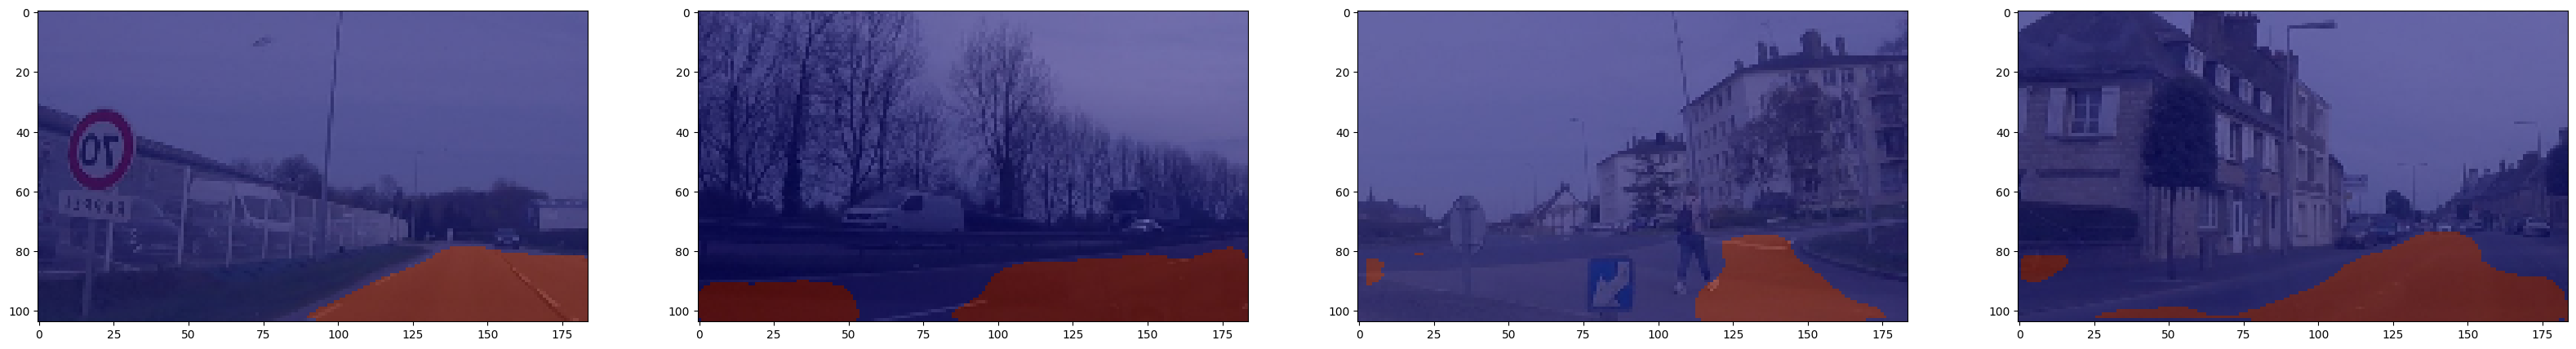

In [45]:
fig, ax = plt.subplots(ncols=4, figsize=(40,20))
for idx in range(4):
    image=test_sample[0][idx]
    mask=yhat[idx]
    ax[idx].imshow(image)
    ax[idx].imshow(np.round(mask), cmap='jet', alpha=0.5)
plt.show()

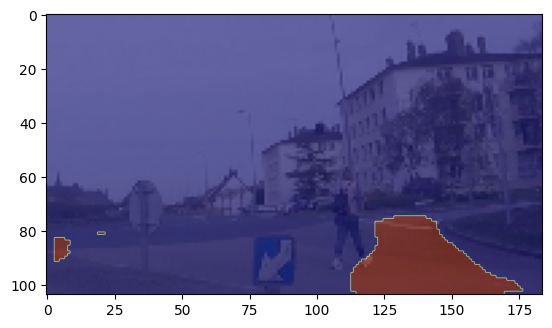

In [46]:
image=test_sample[0][2]
mask=yhat[2]
plt.imshow(image)
plt.imshow(np.round(mask), cmap='jet', alpha=0.5)
plt.show()

1/1 [==============================] - 0s 60ms/step


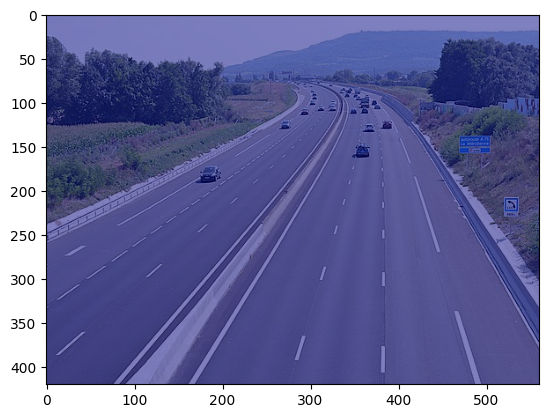

In [53]:
image=plt.imread(os.path.join('route6.jpg'))
resized=cv2.resize(image, (184,104))
test=load_model.predict(np.expand_dims(resized/255,0))
plt.imshow(image)
mask=cv2.resize(np.round(test[0]),image.shape[1::-1])
plt.imshow(mask,cmap='jet',alpha=0.5)